# Reorder points when review happens at discrete times

**How should a buyer set a reorder point when stock is checked daily rather than continuously?** We begin with one SKU and follow its order through the event ledger. Then we use the same demand history for 100 SKUs to compare daily, 12-hour, 6-hour, and 3-hour review. Finally, we evaluate the operating trade-off under declared costs.

The built-in `ReorderPointPolicy` decides **whether and how much to order** from inventory position. Its decision schedule decides **when the rule is consulted**. `SimulationEngine` owns receipts, demand, backlog, and validated events. Stockcast has discrete demand periods; it does not simulate a continuous-time stock sensor.

## 1. A single SKU makes the timing visible

An order decision occurs **before** the current period's demand. Suppose lead time is two daily periods and the buyer can decide every day. If the buyer does not order at period `t`, the next possible order is at `t+1` and arrives before demand at `t+3`. The stock position at `t` therefore faces demand at `t`, `t+1`, and `t+2` before that replacement can help:

| Decision at `t` | Next chance at `t+1` | Next order usable at `t+3` |
|---|---|---|
| Before demand `t` | Before demand `t+1` | Before demand `t+3` |

The relevant demand window is **`H = L + R = 2 + 1 = 3` days**. More generally, if the next opportunity after `t` is `u`, `H = (u − t) + L`. A demand quantile over `H` is a defensible basis for reorder point `s`; it does not promise a particular realized service rate.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from stockcast import InventoryStateDataFrame, ReorderPointPolicy, SimulationEngine
from stockcast.evaluation import (
    InventoryEvaluator, avg_on_hand, backlog_cost, backlog_unit_periods,
    cycle_service_level, fill_rate, holding_cost, ordering_cost, order_units,
    sku_order_line_count, sku_order_quantity_variance, total_cost,
    validate_event_frame,
)


def poisson_quantile(probability, mean):
    # For this artificial example, cumulative demand has a declared Poisson law.
    # The recurrence finds the smallest integer whose CDF reaches probability.
    k, pmf = 0, np.exp(-mean)
    cdf = pmf
    while cdf < probability:
        k += 1
        pmf *= mean / k
        cdf += pmf
    return k

We declare a synthetic demand model of **12 units per day**, a two-day lead time, a 95% *cumulative-demand* quantile for `s`, and fixed order quantity `Q=48`. The ten demand observations below are a deliberately visible replay, not historical sales used to estimate that Poisson model. Opening stock is 40 units with no backlog or pipeline. The first decision is eligible because `review_period=1` creates a daily schedule starting at demand period 0.

The one-SKU path contains a high-demand day so the cost of waiting for the next review is easy to see. Its values are declared; Stockcast does not invent them.

In [3]:
sku = 'widget_A'
opening_date = pd.Timestamp('2026-01-05')
lead_days, review_days = 2, 1
alpha, daily_rate = 0.95, 12.0
fixed_Q = 48.0  # Four days of declared mean demand; not optimized.
coverage_days = lead_days + review_days

# Quantiles of *total* Poisson demand over two different windows.
s_daily = float(poisson_quantile(alpha, daily_rate * coverage_days))
s_lead_only = float(poisson_quantile(alpha, daily_rate * lead_days))
print(f'Correct window H={coverage_days} days gives s={s_daily:.0f}; '
      f'lead-time-only window gives {s_lead_only:.0f}')

Correct window H=3 days gives s=46; lead-time-only window gives 32


Now declare the demand that the engine will replay. The `period` column is zero-based within this run; the first demand date is one day after the opening state. These observations are an example outcome, not inputs to the Poisson quantile above.

In [4]:
single_values = [10, 14, 20, 9, 12, 11, 13, 8, 14, 12]
single_demand = pd.DataFrame({
    'unique_id': [sku] * len(single_values),
    'period': range(len(single_values)),
    'date': pd.date_range(opening_date + pd.Timedelta(days=1),
                          periods=len(single_values), freq='D'),
    'y': single_values,
})
print(single_demand.to_string(index=False))

unique_id  period       date  y
 widget_A       0 2026-01-06 10
 widget_A       1 2026-01-07 14
 widget_A       2 2026-01-08 20
 widget_A       3 2026-01-09  9
 widget_A       4 2026-01-10 12
 widget_A       5 2026-01-11 11
 widget_A       6 2026-01-12 13
 widget_A       7 2026-01-13  8
 widget_A       8 2026-01-14 14
 widget_A       9 2026-01-15 12


`InventoryStateDataFrame.initialize_from_observed()` records the physical opening stock and its date. We specify backlog mode and allocate two lead-time slots explicitly; no opening pipeline or backlog is inferred.

In [5]:
single_opening = InventoryStateDataFrame(
    [sku], max_lead_time=lead_days, allow_backorders=True,
).initialize_from_observed(
    pd.DataFrame({'unique_id': [sku], 'opening_stock': [40.0]}),
    on_hand_column='opening_stock', start_date=opening_date,
)
print(single_opening.inventory_position()[
    ['unique_id', 'on_hand', 'total_in_transit', 'backorders',
     'inventory_position']
].to_string(index=False))

unique_id  on_hand  total_in_transit  backorders  inventory_position
 widget_A     40.0               0.0         0.0                40.0


### Fit the built-in `(s,Q)` rule

`ReorderPointPolicy(policy_type="sQ")` orders a fixed `Q` when **inventory position ≤ `s`**. Inventory position is on-hand plus goods in transit minus backlog. `service_level=0.95` labels the supplied reorder point as a 95% demand quantile; it does **not** calculate the quantile for us.

The `fit()` call binds that externally computed `s` to one SKU and declares exactly what it covers: origin (last available information date), daily frequency, three-period horizon, end date, probability, and `external_direct` source. `get_target_metadata()` lets a user inspect those declarations. Here we deliberately reuse one fixed threshold because the synthetic demand model is stationary. A changing real forecast would require dated updates, as shown in [Notebook 04f](04f_scheduled_forecast_simulation.ipynb).

In [6]:
single_target = pd.DataFrame({
    'unique_id': [sku], 'reorder_q95': [s_daily],
    'target_end': [opening_date + pd.Timedelta(days=coverage_days)],
})
single_policy = ReorderPointPolicy(
    lead_time=lead_days, review_period=review_days, policy_type='sQ',
    service_level=alpha, order_quantity=fixed_Q,
    order_quantity_source='four_days_of_declared_mean_demand',
    allow_backorders=True,
).fit(
    single_target, forecast_origin=opening_date, forecast_frequency='D',
    reorder_point_column='reorder_q95', reorder_end_date_column='target_end',
    reorder_horizon=coverage_days, target_source='external_direct',
    target_probability=alpha,
)
print('Fitted parameters')
print(single_policy.get_parameters().to_string(index=False))
print('Target metadata:', single_policy.get_target_metadata())
print('Decision schedule:', single_policy.schedule.to_manifest())

Fitted parameters
unique_id  reorder_point  order_quantity
 widget_A           46.0            48.0
Target metadata: {'representation': 'direct_reorder_point_target', 'target_probability': 0.95, 'reorder_horizon': 3, 'target_source': 'external_direct', 'order_quantity_source': 'four_days_of_declared_mean_demand', 'forecast_origin': '2026-01-05T00:00:00', 'forecast_frequency': 'D', 'reorder_end_date': '2026-01-08T00:00:00'}
Decision schedule: {'type': 'periodic', 'every': 1, 'start': 0}


Before running the engine, call `predict()` once on the opening state. This returns an `OrderDecision`: a **request**, not a receipt or a state change. Since opening position 40 is below `s=46`, it requests 48 units at demand period 0, due before demand at period 2. The engine will be responsible for accepting and moving that order.

In [7]:
opening_before = single_opening.get_dataframe()
first_decision = single_policy.predict(single_opening, current_period=0)
print(first_decision.get_dataframe().to_string(index=False))
assert single_opening.get_dataframe().equals(opening_before)
assert first_decision.get_dataframe().order_quantity.iloc[0] == fixed_Q
assert first_decision.get_dataframe().expected_delivery_period.iloc[0] == lead_days

unique_id  order_quantity  target_level  inventory_position  reorder_point  order_period  expected_delivery_period
 widget_A            48.0           NaN                40.0           46.0             0                         2


In [8]:
# All ten dated demand rows are scored. The seed is explicitly None because
# this replay consumes a fixed table rather than drawing demand in the engine.
single_run = SimulationEngine().run(
    policy=single_policy, demand_source=single_demand, inventory=single_opening,
    n_periods=len(single_demand), period_frequency='D', initial_decision='none',
    warmup_periods=0, scoring_periods=len(single_demand), settlement_periods=0,
    order_during_settlement=False, demand_source_name='declared_single_sku_path',
    random_seed=None,
)
single_events = validate_event_frame(single_run.to_event_frame(window='scoring'))
single_periods = single_events.loc[single_events.event_type.eq('period')].copy()
columns = ['demand_period', 'date', 'decision_inventory_position',
           'order_quantity', 'received_units', 'demand', 'shortage_units',
           'ending_on_hand', 'backorders_end', 'on_order_end']
print(single_periods[columns].head(6).to_string(index=False,
      float_format=lambda value: f'{value:.1f}'))
assert single_periods.iloc[0].order_quantity == fixed_Q
assert single_periods.iloc[0].received_units == 0
assert single_periods.iloc[lead_days].received_units == fixed_Q

 demand_period       date  decision_inventory_position  order_quantity  received_units  demand  shortage_units  ending_on_hand  backorders_end  on_order_end
             0 2026-01-06                         40.0            48.0             0.0    10.0             0.0            30.0             0.0          48.0
             1 2026-01-07                         78.0             0.0             0.0    14.0             0.0            16.0             0.0          48.0
             2 2026-01-08                         64.0             0.0            48.0    20.0             0.0            44.0             0.0           0.0
             3 2026-01-09                         44.0            48.0             0.0     9.0             0.0            35.0             0.0          48.0
             4 2026-01-10                         83.0             0.0             0.0    12.0             0.0            23.0             0.0          48.0
             5 2026-01-11                         71.0    

The event ledger connects the two APIs. `decision_inventory_position` is what the policy saw before placing an order. `order_quantity` is the accepted request (there are no constraints here). `received_units` appears only when the lead-time pipeline matures. `ending_on_hand` and `backorders_end` are physical outcomes after demand. The figure follows those fields through the ten days.

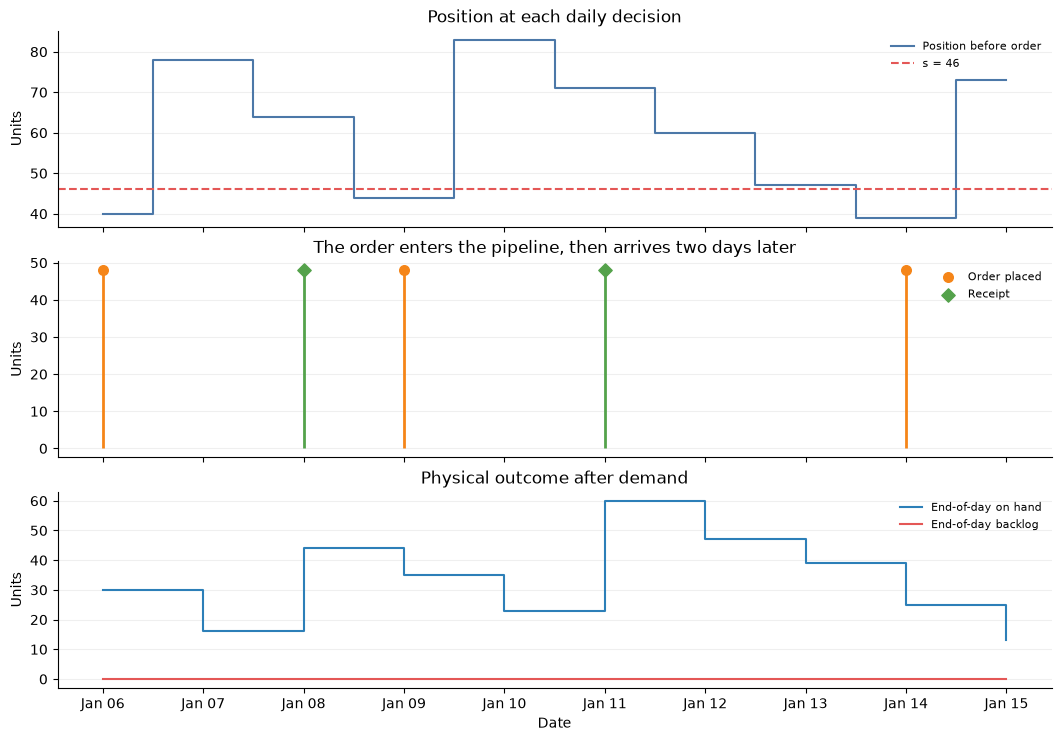

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(10.5, 7.3), sharex=True, layout='constrained')
dates = single_periods.date
axes[0].step(dates, single_periods.decision_inventory_position, where='mid',
             color='#4C78A8', label='Position before order')
axes[0].axhline(s_daily, color='#E45756', linestyle='--', label=f's = {s_daily:.0f}')
axes[0].set(title='Position at each daily decision', ylabel='Units')
# Mark only positive orders and receipts; a daily opportunity need not order.
orders = single_periods.loc[single_periods.order_quantity.gt(0)]
receipts = single_periods.loc[single_periods.received_units.gt(0)]
axes[1].vlines(orders.date, 0, orders.order_quantity, color='#F58518', linewidth=2)
axes[1].scatter(orders.date, orders.order_quantity, color='#F58518', s=48, label='Order placed')
axes[1].vlines(receipts.date, 0, receipts.received_units, color='#54A24B', linewidth=2)
axes[1].scatter(receipts.date, receipts.received_units, color='#54A24B',
                marker='D', s=46, label='Receipt')
axes[1].set(title='The order enters the pipeline, then arrives two days later', ylabel='Units')
axes[2].step(dates, single_periods.ending_on_hand, where='post',
             color='#2C7FB8', label='End-of-day on hand')
axes[2].step(dates, single_periods.backorders_end, where='post',
             color='#E45756', label='End-of-day backlog')
axes[2].set(title='Physical outcome after demand', xlabel='Date', ylabel='Units')
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
for ax in axes:
    ax.legend(frameon=False, loc='upper right', fontsize=8)
    ax.grid(axis='y', alpha=.2)
    ax.spines[['top', 'right']].set_visible(False)
plt.show()

## 2. What if we copy the continuous-review formula?

A classical continuous-review reference sizes `s` over lead-time demand only: here that is the **two-day** quantile. If we pass that number to a daily-review simulator, the policy still has a three-day schedule window. We must label the smaller number as an **external planner choice** (`service_level=None`, column `planner_s`) instead of claiming it is a 95% quantile over three days. Stockcast can validate metadata; it cannot infer how an external number was computed.

`run_comparison` gives both fitted policies the same demand table and isolated copies of the same opening state. This single-SKU comparison is deliberately small enough to inspect each changed event.

In [10]:
# The two-day number cannot carry a 95% label for a three-day
# policy window. Planner mode records it as an external choice.
wrong_policy = ReorderPointPolicy(
    lead_time=lead_days, review_period=review_days,
    policy_type='sQ', service_level=None, order_quantity=fixed_Q,
    order_quantity_source='four_days_of_declared_mean_demand',
    allow_backorders=True,
).fit(
    pd.DataFrame({'unique_id': [sku], 'planner_s': [s_lead_only],
                  'target_end': [opening_date + pd.Timedelta(days=coverage_days)]}),
    forecast_origin=opening_date, forecast_frequency='D',
    reorder_point_column='planner_s', reorder_end_date_column='target_end',
    reorder_horizon=coverage_days, target_source='external_direct',
)
print('Planner target metadata:', wrong_policy.get_target_metadata())

Planner target metadata: {'representation': 'external_reorder_point', 'target_probability': None, 'reorder_horizon': 3, 'target_source': 'external_direct', 'order_quantity_source': 'four_days_of_declared_mean_demand', 'forecast_origin': '2026-01-05T00:00:00', 'forecast_frequency': 'D', 'reorder_end_date': '2026-01-08T00:00:00'}


In [11]:
# run_comparison copies the opening state for each policy and
# feeds both branches the same ten dated demand observations.
one_sku_comparison = SimulationEngine().run_comparison(
    policies=[single_policy, wrong_policy],
    labels=['Correct H=3', 'Copied L=2'],
    demand_source=single_demand, inventory=single_opening,
    n_periods=len(single_demand), period_frequency='D',
    initial_decision='none', warmup_periods=0,
    scoring_periods=len(single_demand), settlement_periods=0,
    order_during_settlement=False,
    demand_source_name='shared_single_sku_path', random_seed=None,
)

Read the **same first four demand periods** from each branch's validated event ledger. This table makes the missed opening order and delayed receipt observable before we move to aggregate statistics.

In [12]:
one_sku_rows = []
for label, run in one_sku_comparison.results.items():
    events = validate_event_frame(run.to_event_frame(window='scoring'))
    one_sku_rows.append(events.loc[events.event_type.eq('period')]
                        .assign(rule=label))
one_sku_events = pd.concat(one_sku_rows, ignore_index=True)
print(one_sku_events.loc[one_sku_events.demand_period.le(3),
      ['rule', 'demand_period', 'decision_inventory_position',
       'order_quantity', 'received_units', 'demand',
       'shortage_units', 'backorders_end']
].to_string(index=False, float_format=lambda value: f'{value:.1f}'))
day_two = one_sku_events.loc[one_sku_events.demand_period.eq(2)].set_index('rule')
assert day_two.loc['Correct H=3', 'shortage_units'] == 0
assert day_two.loc['Copied L=2', 'shortage_units'] > 0

       rule  demand_period  decision_inventory_position  order_quantity  received_units  demand  shortage_units  backorders_end
Correct H=3              0                         40.0            48.0             0.0    10.0             0.0             0.0
Correct H=3              1                         78.0             0.0             0.0    14.0             0.0             0.0
Correct H=3              2                         64.0             0.0            48.0    20.0             0.0             0.0
Correct H=3              3                         44.0            48.0             0.0     9.0             0.0             0.0
 Copied L=2              0                         40.0             0.0             0.0    10.0             0.0             0.0
 Copied L=2              1                         30.0            48.0             0.0    14.0             0.0             0.0
 Copied L=2              2                         64.0             0.0             0.0    20.0         

The correct rule orders before period-0 demand and receives that order before period-2 demand. The copied `L`-only threshold waits until the next daily check, so its first order arrives one day later. On this declared path, that delay produces backlog at period 2. This is a timing counterexample, not a claim that every possible demand path will stock out.

## 3. Generalize to 100 SKUs on one shared demand path

The one-SKU example explains *how* a shortage occurs. Now we ask how review frequency changes outcomes across many SKUs. We draw 35 days of independent synthetic Poisson demand for 100 SKUs in three-hour buckets. Daily, 12-hour, and 6-hour demand are sums of **those same buckets**, so every regime sees the same underlying units over the same physical dates.

The physical lead time stays **two days**, `Q` stays 48 units, and every run starts with the **same 80 units of opening stock per SKU**, no pipeline, and no backlog. The first seven days advance state as warm-up; we compare the same final 28 calendar days. For each review regime we intentionally change both the decision spacing and its matching `H`-window reorder point. The scenario therefore compares complete review regimes, not an isolated causal effect of the schedule alone.

In [13]:
seed = 7
n_skus, days, warmup_days = 100, 35, 7
finest_hours = 3
opening_units = 80.0
panel_origin = pd.Timestamp('2026-01-05')
skus = [f'sku_{i:03d}' for i in range(n_skus)]
rng = np.random.default_rng(seed)
base_buckets = rng.poisson(
    daily_rate * finest_hours / 24,
    size=(days * 24 // finest_hours, n_skus),
).astype(float)
print(f'Base demand: {base_buckets.shape[0]} three-hour periods x '
      f'{base_buckets.shape[1]} SKUs; {base_buckets.sum():.0f} units in all.')

Base demand: 280 three-hour periods x 100 SKUs; 42080 units in all.


`panel_demand()` changes the **row frequency**, not the underlying demand: it groups consecutive three-hour buckets into the requested step. The returned table has one dated SKU row per demand period, as `SimulationEngine.run` requires. We assert equal total demand across frequencies before comparing results.

In [14]:
def panel_demand(step_hours):
    assert step_hours in (3, 6, 12, 24)
    buckets_per_step = step_hours // finest_hours
    by_step = base_buckets.reshape(-1, buckets_per_step, n_skus).sum(axis=1)
    step = pd.Timedelta(hours=step_hours)
    periods = len(by_step)
    return pd.DataFrame({
        'unique_id': np.tile(skus, periods),
        'period': np.repeat(np.arange(periods), n_skus),
        'date': np.repeat([panel_origin + (t + 1) * step for t in range(periods)], n_skus),
        'y': by_step.reshape(-1),
    })

assert all(panel_demand(h).y.sum() == base_buckets.sum() for h in (24, 12, 6, 3))
print('Same total demand at all four frequencies:', int(base_buckets.sum()))

Same total demand at all four frequencies: 42080


### Build each regime with explicit target metadata

`run_regime()` converts two physical days into `L` engine periods. Since each regime checks the rule every period, its correct window is `H=L+1`. The **direct** target is the Poisson quantile of *cumulative demand over that whole window*, never a sum of hourly quantiles.

Quantile mode (`service_level=alpha`) is used only for the correctly sized `(s,Q)` target. The intentionally copied `L`-only value and the later `(s,S)` experiment use planner mode, with no probability claim attached to their policy levels. Each run declares its dates, frequency, opening state, scoring window, demand source, and seed provenance.

First calculate the **design** for one frequency. Two physical lead-time days become `2 × steps_per_day` engine periods. Since the policy reviews each engine period, its correct target horizon is one period longer. This helper returns numbers and dates only; it does not fit a policy or run the simulator.

In [15]:
def regime_design(step_hours, *, threshold_basis='coverage', sizing='sQ'):
    if threshold_basis not in ('coverage', 'lead_only') or sizing not in ('sQ', 'sS'):
        raise ValueError('choose a declared threshold basis and sizing rule')
    steps_per_day = 24 // step_hours
    lead_steps = lead_days * steps_per_day
    horizon = lead_steps + 1  # review_period=1 in engine periods
    basis_steps = horizon if threshold_basis == 'coverage' else lead_steps
    s = float(poisson_quantile(alpha, daily_rate * basis_steps / steps_per_day))
    return {
        'review_hours': step_hours, 'L_steps': lead_steps,
        'H_steps': horizon, 's_window_days': basis_steps / steps_per_day,
        's': s, 'S': s + fixed_Q if sizing == 'sS' else np.nan,
        'frequency': f'{step_hours}h',
        'target_end': panel_origin + horizon * pd.Timedelta(hours=step_hours),
        'threshold_basis': threshold_basis, 'sizing': sizing,
        'quantile_mode': threshold_basis == 'coverage' and sizing == 'sQ',
    }

print('Daily design:', {key: regime_design(24)[key] for key in
      ('L_steps', 'H_steps', 's_window_days', 's', 'target_end')})

Daily design: {'L_steps': 2, 'H_steps': 3, 's_window_days': 3.0, 's': 46.0, 'target_end': Timestamp('2026-01-08 00:00:00')}


Next, `fit_regime_policy()` binds the design to `ReorderPointPolicy`. The **correct `(s,Q)`** target uses quantile mode and its matching probability. The copied `L`-only threshold and the `(s,S)` illustration use planner mode. Their numeric `s` values still come from the declared Poisson calculation, but the policy metadata does not mislabel a planner pair as a calibrated `H`-window quantile.

In [16]:
def fit_regime_policy(design):
    quantile_mode = design['quantile_mode']
    column = 'reorder_q95' if quantile_mode else 'planner_s'
    target = pd.DataFrame({
        'unique_id': skus, column: design['s'],
        'end': design['target_end'],
    })
    if design['sizing'] == 'sS':
        target['S'] = design['S']  # External policy level, not a quantile.
    return ReorderPointPolicy(
        lead_time=design['L_steps'], review_period=1,
        policy_type=design['sizing'],
        service_level=alpha if quantile_mode else None,
        order_quantity=fixed_Q if design['sizing'] == 'sQ' else None,
        order_quantity_source=('four_days_of_mean_demand'
                               if design['sizing'] == 'sQ' else None),
        allow_backorders=True,
    ).fit(
        target, forecast_origin=panel_origin,
        forecast_frequency=design['frequency'],
        reorder_point_column=column, reorder_end_date_column='end',
        reorder_horizon=design['H_steps'], target_source='external_direct',
        target_probability=alpha if quantile_mode else None,
        order_up_to_column='S' if design['sizing'] == 'sS' else None,
    )

print('Daily target metadata:',
      fit_regime_policy(regime_design(24)).get_target_metadata())

Daily target metadata: {'representation': 'direct_reorder_point_target', 'target_probability': 0.95, 'reorder_horizon': 3, 'target_source': 'external_direct', 'order_quantity_source': 'four_days_of_mean_demand', 'forecast_origin': '2026-01-05T00:00:00', 'forecast_frequency': '24h', 'reorder_end_date': '2026-01-08T00:00:00'}


Finally, make a **fresh opening state** and run the matching demand table. `SimulationEngine.run` copies that state, advances the lead-time pipeline, and records events. The short `run_regime()` wrapper makes the four-frequency comparison readable; it returns the run, fitted policy, and declared design separately.

In [17]:
def fresh_panel_opening(lead_steps):
    return InventoryStateDataFrame(
        skus, max_lead_time=lead_steps, allow_backorders=True,
    ).initialize_from_observed(
        pd.DataFrame({'unique_id': skus, 'opening_stock': opening_units}),
        on_hand_column='opening_stock', start_date=panel_origin,
    )

def run_regime(step_hours, *, threshold_basis='coverage', sizing='sQ'):
    design = regime_design(step_hours,
                           threshold_basis=threshold_basis, sizing=sizing)
    policy = fit_regime_policy(design)
    demand = panel_demand(step_hours)
    steps_per_day = 24 // step_hours
    run = SimulationEngine().run(
        policy=policy, demand_source=demand,
        inventory=fresh_panel_opening(design['L_steps']),
        n_periods=len(demand) // n_skus,
        period_frequency=design['frequency'], initial_decision='none',
        warmup_periods=warmup_days * steps_per_day,
        scoring_periods=(days - warmup_days) * steps_per_day,
        settlement_periods=0, order_during_settlement=False,
        demand_source_name='shared_3h_poisson_buckets', random_seed=seed,
    )
    validate_event_frame(run.to_event_frame(window='scoring'))
    return run, policy, design

In [18]:
regimes = {}
designs = {}
for hours in (24, 12, 6, 3):
    run, policy, design = run_regime(hours)
    regimes[hours] = run
    designs[hours] = design
design_table = pd.DataFrame(designs.values()).sort_values('review_hours', ascending=False)
print(design_table[['review_hours', 'L_steps', 'H_steps', 's_window_days', 's']]
      .to_string(index=False, float_format=lambda value: f'{value:.3f}'))
assert design_table.s.is_monotonic_decreasing
assert all(run.to_event_frame('scoring').demand.sum() ==
           regimes[24].to_event_frame('scoring').demand.sum()
           for run in regimes.values())

 review_hours  L_steps  H_steps  s_window_days      s
           24        2        3          3.000 46.000
           12        4        5          2.500 39.000
            6        8        9          2.250 36.000
            3       16       17          2.125 34.000


## 4. Read service, inventory, and order evidence together

`InventoryEvaluator.fit(..., window="scoring")` validates and selects the same final 28 **days** from each run. `groupby=[]` requests one pooled result. We report:

- **fill rate:** demand units served immediately divided by demand units;
- **cycle service:** share of complete receipt-to-receipt SKU cycles without a shortage (opening and terminal partial cycles excluded here);
- **average on-hand:** mean units per SKU-period row;
- **backlog unit-days:** ending backlog multiplied by period length, so results remain comparable across 3-hour and daily rows;
- **positive SKU order lines:** how many actual replenishment lines were placed.

The target probability is a property of the *demand threshold*. Fill rate and cycle service are different realized outcomes, and neither is guaranteed to equal 95%.

In [19]:
service_metrics = [cycle_service_level, fill_rate, avg_on_hand,
                   backlog_unit_periods, sku_order_line_count, order_units]
rows = []
for hours, run in regimes.items():
    measures = InventoryEvaluator().fit(
        simulation_result=run, window='scoring',
    ).evaluate(
        metrics=service_metrics, groupby=[],
        context={'include_partial_cycles': False},
    ).iloc[0].to_dict()
    measures['backlog_unit_days'] = measures['backlog_unit_periods'] * hours / 24
    rows.append({**designs[hours], **measures})
review_results = pd.DataFrame(rows).sort_values('review_hours', ascending=False)
continuous_s = poisson_quantile(alpha, daily_rate * lead_days)
print('Continuous-review lead-time reference:', continuous_s)
print(review_results[[
    'review_hours', 's_window_days', 's', 'cycle_service_level', 'fill_rate',
    'avg_on_hand', 'backlog_unit_days', 'sku_order_line_count',
]].round(3).to_string(index=False))

Continuous-review lead-time reference: 32
 review_hours  s_window_days    s  cycle_service_level  fill_rate  avg_on_hand  backlog_unit_days  sku_order_line_count
           24          3.000 46.0                0.998      1.000       34.393              1.000                 717.0
           12          2.500 39.0                0.988      0.999       33.375             10.500                 713.0
            6          2.250 36.0                0.991      0.999       33.440              6.000                 712.0
            3          2.125 34.0                0.976      0.999       32.788              9.375                 711.0


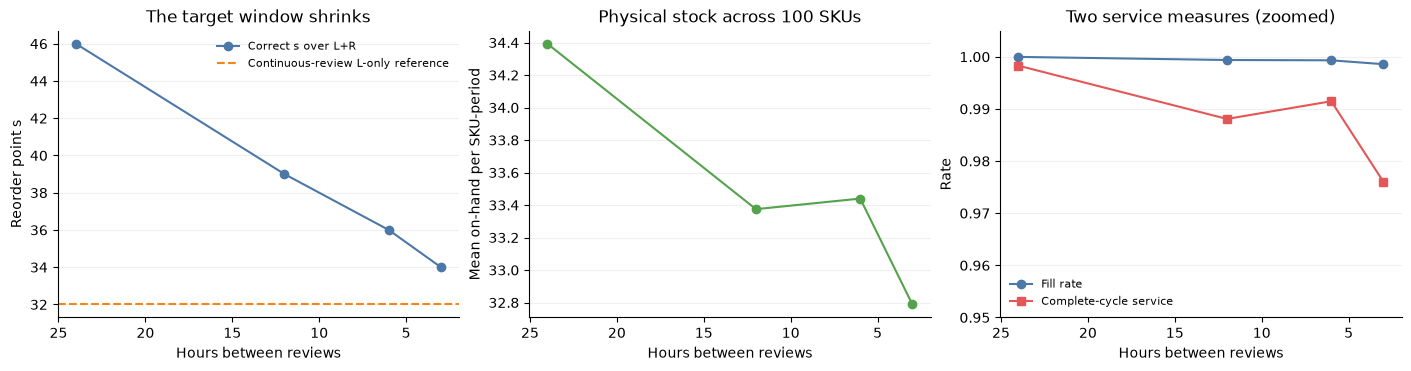

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6), layout='constrained')
x = review_results.review_hours
axes[0].plot(x, review_results.s, marker='o', color='#4C78A8', label='Correct s over L+R')
axes[0].axhline(continuous_s, color='#F58518', linestyle='--',
                label='Continuous-review L-only reference')
axes[0].set(title='The target window shrinks', xlabel='Hours between reviews', ylabel='Reorder point s')
axes[0].legend(frameon=False, fontsize=8)
axes[1].plot(x, review_results.avg_on_hand, marker='o', color='#54A24B')
axes[1].set(title='Physical stock across 100 SKUs', xlabel='Hours between reviews',
            ylabel='Mean on-hand per SKU-period')
axes[2].plot(x, review_results.fill_rate, marker='o', color='#4C78A8', label='Fill rate')
axes[2].plot(x, review_results.cycle_service_level, marker='s', color='#E45756',
             label='Complete-cycle service')
axes[2].set(title='Two service measures (zoomed)', xlabel='Hours between reviews',
            ylabel='Rate', ylim=(0.95, 1.005))
axes[2].legend(frameon=False, fontsize=8)
for ax in axes:
    ax.invert_xaxis()
    ax.grid(axis='y', alpha=.2)
    ax.spines[['top', 'right']].set_visible(False)
plt.show()

Each SKU sees its own random path even though every SKU has the same declared Poisson rate. The pooled mean can hide that spread. The next plot uses `groupby=['unique_id']` to show each SKU's average stock and the distribution of its *change* from daily to three-hour review. The demand history remains fixed across regimes. The service plot above is zoomed to 95–100% so its small differences are legible; the exact values are in the table.

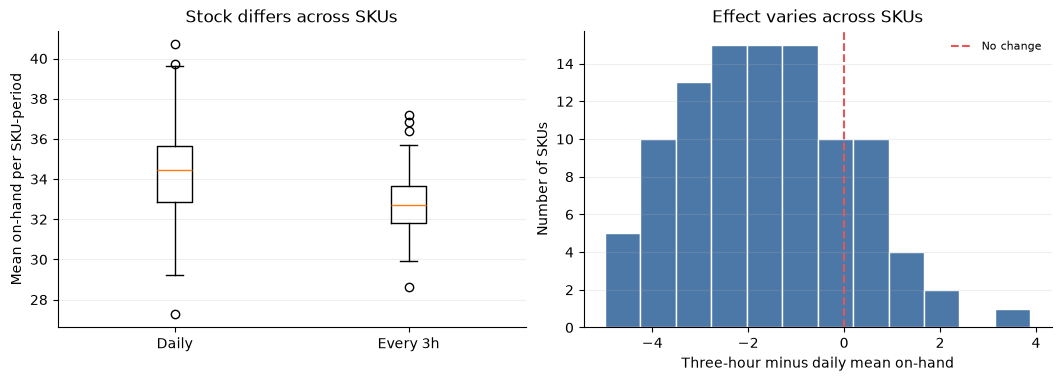

In [21]:
per_sku = {}
for hours in (24, 3):
    per_sku[hours] = InventoryEvaluator().fit(
        simulation_result=regimes[hours], window='scoring',
    ).evaluate(metrics=[avg_on_hand, fill_rate], groupby=['unique_id']).set_index('unique_id')
assert per_sku[24].index.equals(per_sku[3].index)
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.7), layout='constrained')
axes[0].boxplot([per_sku[24].avg_on_hand, per_sku[3].avg_on_hand],
                tick_labels=['Daily', 'Every 3h'])
axes[0].set(title='Stock differs across SKUs', ylabel='Mean on-hand per SKU-period')
stock_change = per_sku[3].avg_on_hand - per_sku[24].avg_on_hand
axes[1].hist(stock_change, bins=12, color='#4C78A8', edgecolor='white')
axes[1].axvline(0, color='#E45756', linestyle='--', label='No change')
axes[1].set(title='Effect varies across SKUs',
            xlabel='Three-hour minus daily mean on-hand', ylabel='Number of SKUs')
axes[1].legend(frameon=False, fontsize=8)
for ax in axes:
    ax.grid(axis='y', alpha=.2)
    ax.spines[['top', 'right']].set_visible(False)
plt.show()

## 5. Repeat the wrong-window experiment across the panel

The single-SKU counterexample showed the mechanism. We now hold **daily** review, the same 100 SKU demand table, fixed opening stock, lead time, `Q`, and evaluation window constant. The only policy input we change is the reorder point: the correct 3-day quantile versus the copied 2-day reference. The copied value enters planner mode because it is not a 95% quantile over the required three-day window.

This is a controlled threshold comparison, not a test of forecast model quality. Both values came from the same declared Poisson model with different horizons.

In [22]:
wrong_daily_run, wrong_daily_policy, wrong_design = run_regime(
    24, threshold_basis='lead_only',
)
wrong_measures = InventoryEvaluator().fit(
    simulation_result=wrong_daily_run, window='scoring',
).evaluate(
    metrics=service_metrics, groupby=[],
    context={'include_partial_cycles': False},
).iloc[0].to_dict()
correct_daily = review_results.loc[review_results.review_hours.eq(24)].iloc[0]
wrong_table = pd.DataFrame([
    {'threshold': 'Correct L+R', 's': correct_daily.s,
     'cycle_service': correct_daily.cycle_service_level,
     'fill_rate': correct_daily.fill_rate,
     'avg_on_hand': correct_daily.avg_on_hand,
     'backlog_unit_days': correct_daily.backlog_unit_days,
     'order_lines': correct_daily.sku_order_line_count},
    {'threshold': 'Copied L only', 's': wrong_design['s'],
     'cycle_service': wrong_measures['cycle_service_level'],
     'fill_rate': wrong_measures['fill_rate'],
     'avg_on_hand': wrong_measures['avg_on_hand'],
     'backlog_unit_days': wrong_measures['backlog_unit_periods'],
     'order_lines': wrong_measures['sku_order_line_count']},
])
assert wrong_table.loc[1, 'cycle_service'] < wrong_table.loc[0, 'cycle_service']
print(wrong_table.round(3).to_string(index=False))

    threshold    s  cycle_service  fill_rate  avg_on_hand  backlog_unit_days  order_lines
  Correct L+R 46.0          0.998      1.000       34.393                1.0        717.0
Copied L only 32.0          0.664      0.966       21.001             1143.0        703.0


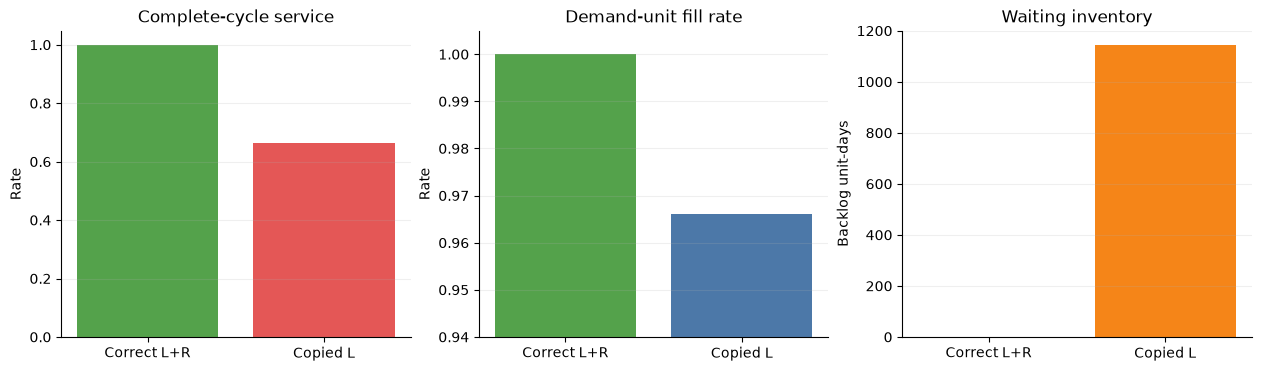

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.6), layout='constrained')
labels = ['Correct L+R', 'Copied L']
for ax, column, title, color in [
    (axes[0], 'cycle_service', 'Complete-cycle service', '#E45756'),
    (axes[1], 'fill_rate', 'Demand-unit fill rate', '#4C78A8'),
    (axes[2], 'backlog_unit_days', 'Waiting inventory', '#F58518'),
]:
    ax.bar(labels, wrong_table[column], color=['#54A24B', color])
    ax.set(title=title, ylabel='Backlog unit-days' if column == 'backlog_unit_days' else 'Rate')
    if column == 'fill_rate':
        ax.set_ylim(.94, 1.005)  # Zoom only this near-one measure.
    ax.grid(axis='y', alpha=.2)
    ax.spines[['top', 'right']].set_visible(False)
plt.show()

Cycle service asks whether **each complete receipt-to-receipt cycle** avoided *any* shortage. Fill rate asks what share of **all demand units** was served immediately. A regime can fill nearly all units while many cycles each contain a small shortage. The copied threshold raises that risk here; it does not make every individual cycle fail. We report both measures because they answer different operational questions.

## 6. Make an operating choice with explicit costs

Faster review may reduce stock and backlog, while requiring more checks. We evaluate the **same 28 scored days** for every frequency. `InventoryEvaluator` computes three supported costs from validated events: fixed cost per positive SKU order line, holding cost on end-of-period stock, and backlog waiting cost on end-of-period backlog. Holding and backlog rates below are declared **per day**, so we multiply each by `step_hours/24` before evaluating a shorter period. Fixed order-line cost needs no time conversion.

Stockcast does not have a built-in charge for inspecting a SKU when no order is placed. We add a separately labelled, illustrative administrative charge of `0.02` per SKU review opportunity *outside* `total_cost`. This makes the operating assumption inspectable and prevents it from being mistaken for an engine transaction. We compare only these four declared regimes and costs; the minimum is not a universal optimum.

In [24]:
# These artificial rates describe one operating scenario.
order_line_fee = 5.0
holding_per_unit_day = 0.05
backlog_per_unit_day = 1.0
review_fee_per_sku_check = 0.02
scored_days = days - warmup_days

def cost_context_for(step_hours):
    step_fraction = step_hours / 24
    return {
        'cost_components': ['ordering', 'holding', 'backlog'],
        'order_cost_per_sku_line': order_line_fee,
        'order_cost_per_unit': 0.0,
        'holding_cost_per_unit_period': holding_per_unit_day * step_fraction,
        'backlog_cost_per_unit_period': backlog_per_unit_day * step_fraction,
    }

print('Daily cost rates:', cost_context_for(24))
print('Three-hour cost rates:', cost_context_for(3))

Daily cost rates: {'cost_components': ['ordering', 'holding', 'backlog'], 'order_cost_per_sku_line': 5.0, 'order_cost_per_unit': 0.0, 'holding_cost_per_unit_period': 0.05, 'backlog_cost_per_unit_period': 1.0}
Three-hour cost rates: {'cost_components': ['ordering', 'holding', 'backlog'], 'order_cost_per_sku_line': 5.0, 'order_cost_per_unit': 0.0, 'holding_cost_per_unit_period': 0.00625, 'backlog_cost_per_unit_period': 0.125}


`InventoryEvaluator.evaluate()` now applies those rates to each regime's **validated scoring events**. It charges only positive order lines, stock held at each period end, and waiting backlog. `total_cost` is the sum of the three activated components; it does not know about the separate review-check charge.

In [25]:
cost_rows = []
for hours, run in regimes.items():
    cost = InventoryEvaluator().fit(
        simulation_result=run, window='scoring',
    ).evaluate(
        metrics=[ordering_cost, holding_cost, backlog_cost, total_cost],
        groupby=[], context=cost_context_for(hours),
    ).iloc[0].to_dict()
    cost_rows.append({'review_hours': hours, **cost})
cost_table = pd.DataFrame(cost_rows).sort_values(
    'review_hours', ascending=False,
)
assert np.allclose(
    cost_table.total_cost,
    cost_table[['ordering_cost', 'holding_cost', 'backlog_cost']].sum(axis=1),
)

We add the **external** review effort only after obtaining Stockcast's event costs. Every SKU is checked at each scheduled opportunity, including checks that produce no order. The comparison table keeps the two totals separate so readers can change this business assumption.

In [26]:
cost_table['sku_reviews'] = (
    n_skus * scored_days * (24 // cost_table.review_hours)
).astype(int)
cost_table['external_review_cost'] = (
    cost_table.sku_reviews * review_fee_per_sku_check
)
cost_table['cost_including_reviews'] = (
    cost_table.total_cost + cost_table.external_review_cost
)
chosen_hours = int(cost_table.sort_values(
    ['cost_including_reviews', 'review_hours'],
).iloc[0].review_hours)
print(cost_table.round(2).to_string(index=False))
print(f'Lowest cost among these four regimes: every {chosen_hours} hours')

 review_hours  ordering_cost  holding_cost  backlog_cost  total_cost  sku_reviews  external_review_cost  cost_including_reviews
           24         3585.0       4815.05          1.00     8401.05         2800                  56.0                 8457.05
           12         3565.0       4672.48         10.50     8247.98         5600                 112.0                 8359.98
            6         3560.0       4681.59          6.00     8247.59        11200                 224.0                 8471.59
            3         3555.0       4590.35          9.38     8154.72        22400                 448.0                 8602.72
Lowest cost among these four regimes: every 12 hours


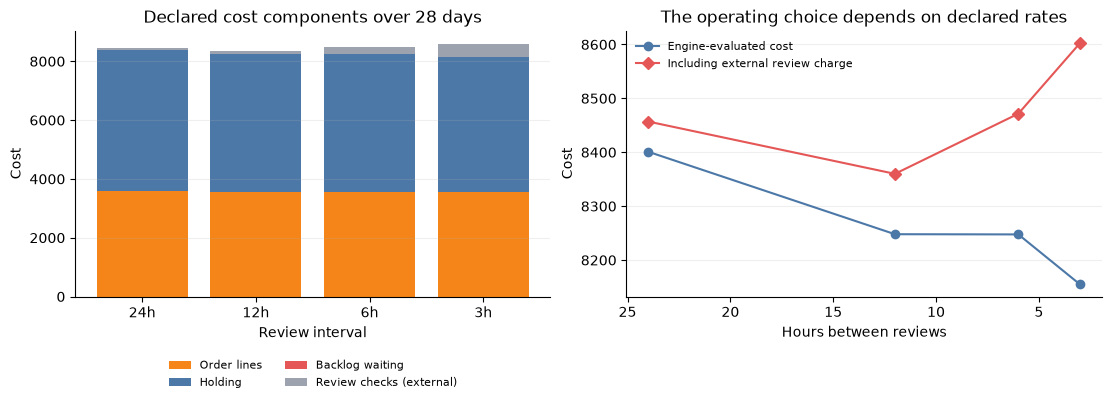

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.9), layout='constrained')
x = np.arange(len(cost_table))
bottom = np.zeros(len(cost_table))
for column, label, color in [
    ('ordering_cost', 'Order lines', '#F58518'),
    ('holding_cost', 'Holding', '#4C78A8'),
    ('backlog_cost', 'Backlog waiting', '#E45756'),
    ('external_review_cost', 'Review checks (external)', '#9CA3AF'),
]:
    axes[0].bar(x, cost_table[column], bottom=bottom, color=color, label=label)
    bottom += cost_table[column].to_numpy()
axes[0].set_xticks(x, [f'{hours}h' for hours in cost_table.review_hours])
axes[0].set(title='Declared cost components over 28 days', xlabel='Review interval', ylabel='Cost')
axes[0].legend(frameon=False, fontsize=8, loc='upper center',
               bbox_to_anchor=(.5, -.2), ncol=2)
axes[1].plot(cost_table.review_hours, cost_table.total_cost,
             marker='o', color='#4C78A8', label='Engine-evaluated cost')
axes[1].plot(cost_table.review_hours, cost_table.cost_including_reviews,
             marker='D', color='#E45756', label='Including external review charge')
axes[1].invert_xaxis()
axes[1].set(title='The operating choice depends on declared rates',
            xlabel='Hours between reviews', ylabel='Cost')
axes[1].legend(frameon=False, fontsize=8)
for ax in axes:
    ax.grid(axis='y', alpha=.2)
    ax.spines[['top', 'right']].set_visible(False)
plt.show()

Under the declared rates, the event-based cost alone is lowest with three-hour review. Adding the separately calculated check charge makes **12-hour review** the lowest-cost choice among these four regimes in this replay. The table shows both totals, so a reader can replace that illustrative charge with their own operating rate.

## Optional extension: `(s,S)` order sizing

The review-frequency and cost comparison is complete above. This short section shows another sizing mode of the same built-in policy.

So far the threshold is `s` and every positive order is exactly `Q=48`. `ReorderPointPolicy(policy_type="sS")` keeps the same trigger but requests enough to reach an external level `S`: `max(0, S − inventory position)`. We set `S=s+48` **as an illustrative policy choice**, use the same daily schedule and demand, and compare the resulting order sizes. At the threshold it requests 48 units; below the threshold it requests more. With multiplier one, this is the shortfall-responsive rule illustrated as a custom extension in Notebook 05. The built-in form is preferable when that standard rule is all you need.

We reuse the same numeric `s=46` but now declare `s` and `S` as a policy pair in planner mode (`service_level=None`). `S` has no quantile probability, and this demonstration does not optimize the pair.

In [28]:
ss_daily_run, ss_daily_policy, ss_design = run_regime(24, sizing='sS')
print('Built-in (s,S) parameters')
print(ss_daily_policy.get_parameters().head(3).to_string(index=False))
print('Target metadata:', ss_daily_policy.get_target_metadata())

daily_cost_context = {
    'cost_components': ['ordering', 'holding', 'backlog'],
    'order_cost_per_sku_line': order_line_fee, 'order_cost_per_unit': 0.0,
    'holding_cost_per_unit_period': holding_per_unit_day,
    'backlog_cost_per_unit_period': backlog_per_unit_day,
    'include_partial_cycles': False,
}
policy_rows = []
for label, run in [('Fixed (s,Q)', regimes[24]), ('Variable (s,S)', ss_daily_run)]:
    row = InventoryEvaluator().fit(
        simulation_result=run, window='scoring',
    ).evaluate(
        metrics=[cycle_service_level, fill_rate, avg_on_hand,
                 sku_order_line_count, sku_order_quantity_variance, total_cost],
        groupby=[], context=daily_cost_context,
    ).iloc[0].to_dict()
    policy_rows.append({'rule': label, **row})
policy_table = pd.DataFrame(policy_rows)
print(policy_table.round(3).to_string(index=False))

Built-in (s,S) parameters
unique_id  reorder_point  order_up_to_level
  sku_000           46.0               94.0
  sku_001           46.0               94.0
  sku_002           46.0               94.0
Target metadata: {'representation': 'external_reorder_point', 'target_probability': None, 'reorder_horizon': 3, 'target_source': 'external_direct', 'order_quantity_source': None, 'forecast_origin': '2026-01-05T00:00:00', 'forecast_frequency': '24h', 'reorder_end_date': '2026-01-08T00:00:00', 'order_up_to_representation': 'external_policy_level'}


          rule  cycle_service_level  fill_rate  avg_on_hand  sku_order_line_count  sku_order_quantity_variance  total_cost
   Fixed (s,Q)                0.998        1.0       34.393                 717.0                        0.000     8401.05
Variable (s,S)                0.994        1.0       37.086                 634.0                       17.191     8368.10


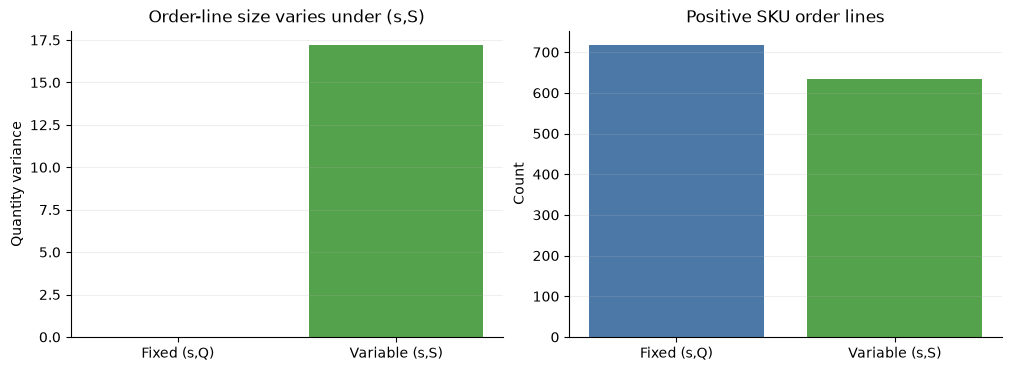

In [29]:
# Variance of positive line sizes and the number of lines show how the
# two built-in sizing rules change orders. Cost remains visible in the table.
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6), layout='constrained')
axes[0].bar(policy_table.rule, policy_table.sku_order_quantity_variance,
            color=['#4C78A8', '#54A24B'])
axes[0].set(title='Order-line size varies under (s,S)', ylabel='Quantity variance')
axes[1].bar(policy_table.rule, policy_table.sku_order_line_count,
            color=['#4C78A8', '#54A24B'])
axes[1].set(title='Positive SKU order lines', ylabel='Count')
for ax in axes:
    ax.grid(axis='y', alpha=.2)
    ax.spines[['top', 'right']].set_visible(False)
plt.show()

## What to carry into your own work

1. Choose the **decision schedule and physical lead time** first. For a periodic review every `R` periods, size the reorder point over cumulative demand through `L+R`. A faster discrete review moves toward the continuous-review reference but never creates a continuous-time simulator.
2. Declare how `s` was obtained. `service_level` and `target_probability` describe a genuine quantile over the validated window; use planner mode for a separately chosen threshold. Keep the origin, frequency, horizon, and end date aligned.
3. Check outcomes in the **validated event ledger**. A target probability is not a fill-rate or cycle-service promise. Shared demand, opening stock, and physical time make comparisons interpretable.
4. Evaluate costs with explicit rates and units. Here the review-check fee was computed outside Stockcast; the selected regime is conditional on those artificial rates, four candidate schedules, one realized demand panel, and a fixed `Q`.

[Notebook 04f](04f_scheduled_forecast_simulation.ipynb) shows dated forecast targets on an irregular schedule. [Notebook 05](05_custom_policies.ipynb) teaches custom policy code, while this notebook uses the built-in reorder-point policy. [Notebook 06](06_fair_forecast_and_policy_comparisons.ipynb) expands controlled forecast and policy comparisons.